# Wen et al. 1D Data: Path Lifting & Analysis

This notebook demonstrates the full pipeline on real 1D grid cell data from Wen et al. (https://www.nature.com/articles/s41586-024-08034-3):
1. Load spike data and position from the Wen dataset
2. Perform spectral analysis to identify grid cell modules
3. Extract toroidal coordinates and apply path lifting
4. Segment the 1D trajectory by laps and compute per-segment mismatch scores
5. Visualize reconstruction quality across segments

In [1]:
import os, sys
sys.path.append('..')

import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

from constants import WEN_DATA_PATH
from helper_scripts.spectral_analysis import convert_raw_data, spectral_analysis
from toroidal_coordinates.compute_coord import interp_arr
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from pipelines import (
    recover_traj_pipeline,
    compare_lifted_pipeline,
    compare_lifted_1d_pipeline,
    segmental_compare_1d_pipeline,
    plot_trajectory_comparison,
)

In [2]:
def plot_toroidal_coordinates_oneD_segment(xx: np.ndarray, yy: np.ndarray, coords:np.ndarray,
                              **kwargs) -> None:
    """
    Visualizes toroidal coordinates. 
    Differs from the previous plotting functions by (1) uses "plasma" colormap and (2) uses the original coordinates instead of cosine values.

    Args:
        xx (np.ndarray): X-coordinates position
        yy (np.ndarray): spatial bins
        coords (np.ndarray): Array of toroidal coordinates.
        aspect_equal (bool): Whether to set the aspect ratio to be equal.
    """
    
   
    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    

    coords_color = [coords[:, 0], coords[:,1]]

    sc0 = ax[0].scatter(xx, yy, c=coords_color[0], cmap='plasma', **kwargs)
    ax[0].set_xticks([0, 100, 200, 300])
    ax[0].tick_params(axis = "both", which = "major", labelsize = 25)
    ax[0].set_xlabel("Position (cm)", fontsize = 30)
    ax[0].set_ylabel("Spatial bin ", fontsize = 30)
    #ax[0].set_yticks([])


    sc1 = ax[1].scatter(xx, yy, c=coords_color[1], cmap='plasma', **kwargs)
    ax[1].set_xticks([0, 100, 200, 300])
    ax[1].tick_params(axis = "both", which = "major", labelsize = 25)
    ax[1].set_xlabel("Position (cm)", fontsize = 30)
    ax[1].set_ylabel("Spatial bin", fontsize = 30)
    #ax[1].set_yticks([])

    
    pos = ax[1].get_position()
    
    # Compute colorbar dimensions:
    # Width: 1/3 of the scatter plot width.
    width_ax = pos.width
    width_cbar = width_ax * (1/10)
    # Height: 80% of scatter plot height.
    height_ax = pos.height
    height_cbar = height_ax * 0.95
    # Horizontal pad between ax[1] and colorbar.
    pad = 0.02  
    x_cbar = pos.x1 + pad
    y_cbar = pos.y0 + (height_ax - height_cbar) / 2

    # Add a new axis for the colorbar at the computed position.
    cax = fig.add_axes([x_cbar, y_cbar, width_cbar, height_cbar]) # type: ignore
   
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(vmin = 0, vmax = 2 * math.pi), cmap = "plasma"), 
                        cax=cax, ticks=np.arange(0, 2*math.pi+0.001, math.pi), format=mticker.FixedFormatter(['0', r'$\pi$', r'$2\pi$']))
    
    cbar.set_ticks(np.arange(0, 2*math.pi+0.001, math.pi))
    cbar.ax.tick_params(labelsize=25)

In [3]:
def analyze_linearity_with_pca(points, plot_and_print=False, save_path=None):
    """
    Analyzes the linearity of a set of 2D points using PCA.
    
    Args:
        points (np.ndarray): Array of shape (n, 2) with x and y coordinates.
        plot_and_print (bool): Whether to plot the PCA line and print explained variances.
        save_path (str): If provided, saves the figure to this file path (as PDF).
    
    Returns:
        tuple: (explained_variance_ratio_pc1, explained_variance_ratio_pc2)
    """

    
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(points)
    
    # Get explained variance ratios
    explained_var_ratio_pc1 = pca.explained_variance_ratio_[0]
    explained_var_ratio_pc2 = pca.explained_variance_ratio_[1]
    
    if plot_and_print:
        print(f"PC1 Explained Variance Ratio: {explained_var_ratio_pc1:.4f}")
        print(f"PC2 Explained Variance Ratio: {explained_var_ratio_pc2:.4f}")
        
        colors = plt.cm.viridis(np.linspace(0, 1, points.shape[0]))
        plt.figure(figsize=(6, 5))
        plt.scatter(points[:, 0], points[:, 1], color=colors, marker='.', s=200)
        
        # Plot the first principal component line
        mean = pca.mean_
        pc1 = pca.components_[0]
        
        # Span the line across the full range of the data projected onto PC1
        projections = (points - mean) @ pc1
        t = np.linspace(projections.min(), projections.max(), 100)
        line = mean + t[:, np.newaxis] * pc1
        plt.plot(line[:, 0], line[:, 1], 'r-', linewidth=2)
        
        plt.tick_params(axis='both', which='major', labelsize=25)
        #plt.axis('equal')
        plt.xlabel("Reconstructed position(x)", fontsize=30)
        plt.ylabel("Reconstructed position(y)", fontsize=30)
        if save_path is not None:
            plt.savefig(save_path, transparent=True, bbox_inches="tight")
        plt.show()
    
    return explained_var_ratio_pc1, explained_var_ratio_pc2


## 1. Load Wen Data

Using session `N2_200203_buildup_track` from the Wen et al. dataset (1D linear track).

This code is provided by https://github.com/GiocomoLab/mec-rapid-learning/tree/main

See the following for dictionary keys https://data.mendeley.com/datasets/rgtk6jygjc/1

In [4]:
FNAME = 'N2_200203_buildup_track'

mat_data = sio.loadmat(os.path.join(WEN_DATA_PATH, FNAME + '.mat'))
print(f"Keys: {list(mat_data.keys())}")

position = mat_data['posx'][:, 0]
post = mat_data['post'][:, 0]
print(f"Position shape: {position.shape}, Time shape: {post.shape}")
print(f"All maps shape: {mat_data['all_maps'].shape}  (n_cells x n_trials x n_spatial_bins)")

Keys: ['__header__', '__version__', '__globals__', 'all_maps', 'lickt', 'lickx', 'post', 'posx', 'trial_starts', 'clu_ids', 'sp']
Position shape: (209275,), Time shape: (209275,)
All maps shape: (201, 619, 160)  (n_cells x n_trials x n_spatial_bins)


Note that the bins here are spatial bins. We should have 160 * 619 = 99040 total spatial bins

In [5]:
position_spatial_bins = [i for i in range(0, 320, 2)] * 619
print("number of spatial bins:", len(position_spatial_bins))

number of spatial bins: 99040


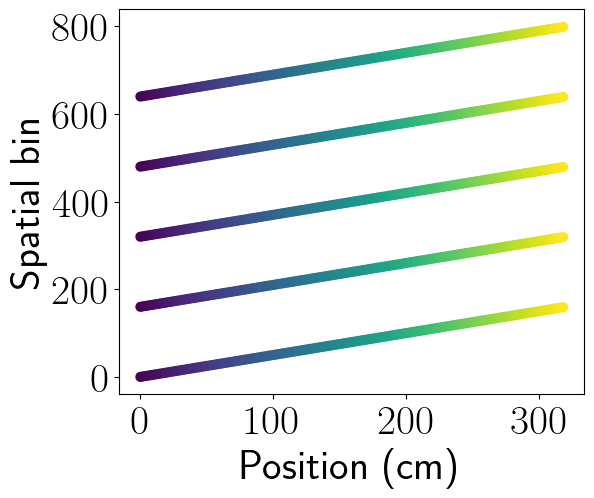

In [6]:
max_index = 5
fig = plt.figure(figsize = (6,5))

for i in range(max_index):
    start_idx = i * 160
    end_idx = (i+1) * 160
    plt.scatter(position_spatial_bins[start_idx:end_idx], [j for j in range(start_idx, end_idx)],
                c=np.arange(end_idx - start_idx), cmap="viridis", s=40)

plt.xlabel("Position (cm)", fontsize=30)
plt.ylabel("Spatial bin", fontsize = 30)
plt.xticks([0, 100, 200, 300], fontsize = 30)
plt.yticks([0, 200, 400, 600, 800], fontsize = 30)
#plt.savefig("position vs spatial bin.pdf")
plt.show()

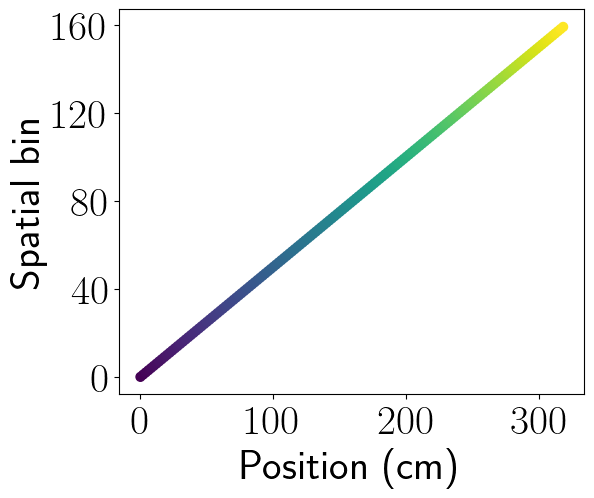

In [7]:
# plot one segment
max_index = 1
fig = plt.figure(figsize = (6,5))

for i in range(max_index):
    start_idx = i * 160
    end_idx = (i+1) * 160
    plt.scatter(position_spatial_bins[start_idx:end_idx], [j for j in range(start_idx, end_idx)],
                c=np.arange(end_idx - start_idx), cmap="viridis", s=40)

plt.xlabel("Position (cm)", fontsize=30)
plt.ylabel("Spatial bin", fontsize = 30)
plt.xticks([0, 100, 200, 300], fontsize = 30)
plt.yticks([0, 40, 80, 120, 160], fontsize = 30)
#plt.savefig("position vs spatial bin single.pdf")
plt.show()

## 2. Spectral Analysis & Grid Cell Module Selection

Use spectral analysis to cluster neurons into grid cell modules, then select the first (finest scale) module.

In [8]:
maps_data = convert_raw_data(mat_data, FNAME)
results = spectral_analysis(maps_data)
grid_cell_idxs_modules = results.grid_cell_idxs_modules

print(f"Number of modules: {len(grid_cell_idxs_modules)}")
for i, idxs in enumerate(grid_cell_idxs_modules):
    print(f"  Module {i}: {len(idxs)} cells")

201 cells, 619 trials, 160 spatial bins
Identified 5 candidate modules
Number of modules: 5
  Module 0: 44 cells
  Module 1: 31 cells
  Module 2: 12 cells
  Module 3: 19 cells
  Module 4: 21 cells


In [9]:
# Use module 0 (finest scale) — reshape to (n_cells, n_trials * n_spatial_bins)
m1 = mat_data['all_maps'][grid_cell_idxs_modules[0]]
all_m1 = np.reshape(m1, (m1.shape[0], m1.shape[1] * m1.shape[2]))
print(f"Activity matrix shape: {all_m1.shape}  (n_cells x n_timepoints)")

Activity matrix shape: (44, 99040)  (n_cells x n_timepoints)


## 3. Extract Toroidal Coordinates & Apply Path Lifting

In [10]:
# recover_traj_pipeline expects activity in shape (n_cells, n_timesteps)
tor_coord, lifted = recover_traj_pipeline(all_m1)

print(f"Toroidal coord shape: {tor_coord.shape}")
print(f"Lifted coord shape:   {lifted.shape}")

dreimac failed, falling back to gardner


/home/hyoon/GridPathLifting/example/../toroidal_coordinates/Gardner_toroidal.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 0.20700955874350147
Toroidal coord shape: (98784, 2)
Lifted coord shape:   (98784, 2)


While we started with 99040 spatial bins, we only have 98784 points because there are certain bins where there is no grid cell activity recorded.

In [11]:
# index of bins where there is no grid cell activity (zero across all neurons)
bins_with_zero_activity = np.where(np.sum(all_m1.T > 0, 1) == 0)[0]

# Normalize to a set even if bins_with_zero_activity is a scalar int
zero_activity_bins = set(np.atleast_1d(bins_with_zero_activity).astype(int).tolist())

intersecting_bins = []
for bin_idx in range(619):
    start_bin = 160 * bin_idx
    end_bin = 160 * (bin_idx + 1)

    bins_in_range = set(range(start_bin, end_bin))
    if bins_in_range & zero_activity_bins:
        intersecting_bins.append(bin_idx)

print(intersecting_bins)

[176, 618]


We therefore need to exclude runs 176 and 618 from our analysis. In fact, we focus on the 441 runs between run 176 and run 618


In [12]:
activity_2 = all_m1.T[177*160: 618 * 160,:]
n_segments = activity_2.shape[0] // 160
print("number of segments in activity 2:", n_segments)

number of segments in activity 2: 441


In [13]:
# recover_traj_pipeline expects activity in shape (n_cells, n_timesteps)
tor_coord2, lifted2 = recover_traj_pipeline(activity_2.T)

print(f"Toroidal coord shape: {tor_coord2.shape}")
print(f"Lifted coord shape:   {lifted2.shape}")

dreimac failed, falling back to gardner


/home/hyoon/GridPathLifting/example/../toroidal_coordinates/Gardner_toroidal.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 0.2149928567334598
Toroidal coord shape: (70560, 2)
Lifted coord shape:   (70560, 2)


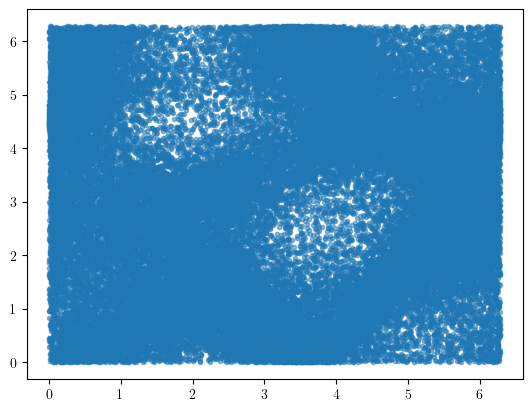

In [14]:
plt.figure()
plt.scatter(tor_coord2[:, 0], tor_coord2[:, 1], marker='.', alpha=0.5)
plt.show()

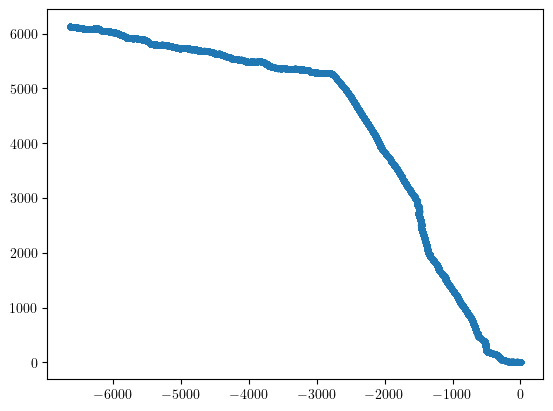

In [15]:
plt.figure()
plt.plot(lifted2[:, 0], lifted2[:, 1], marker='.')
plt.show()

## 4. Linearity scores

In [16]:
segment_idx = 200
coords2_segment = tor_coord2[segment_idx*160:(segment_idx+1)*160]
lifted_segment = toroidal_lifting_distance_upgrade(coords2_segment)

DISTANCE_THRESHOLD: 3.7280211968151695


In [17]:
from sklearn.decomposition import PCA
import matplotlib as mpl
import matplotlib.ticker as mticker

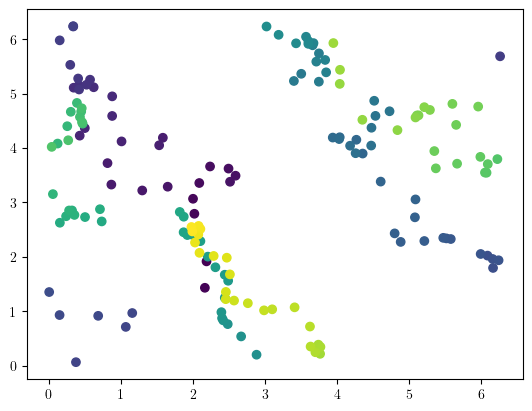

In [18]:
colors = plt.cm.viridis(np.linspace(0, 1, coords2_segment.shape[0]))
plt.scatter(coords2_segment[:, 0], coords2_segment[:, 1], c=colors)
plt.show()

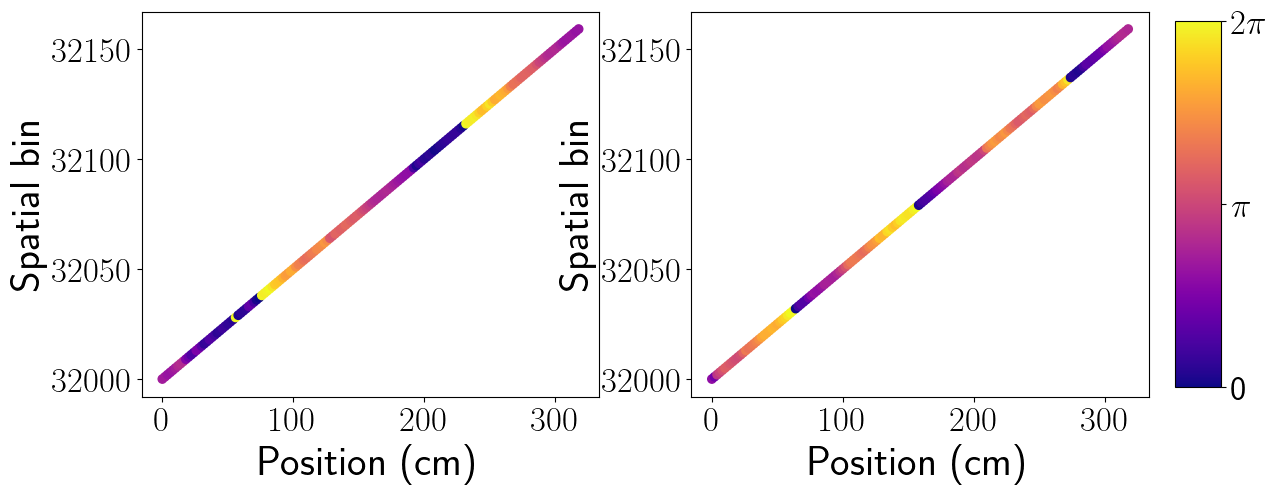

In [19]:
plot_toroidal_coordinates_oneD_segment(position_spatial_bins[segment_idx*160:(segment_idx+1)*160], [j for j in range(segment_idx*160, (segment_idx+1)*160)], coords2_segment)

PC1 Explained Variance Ratio: 0.9911
PC2 Explained Variance Ratio: 0.0089


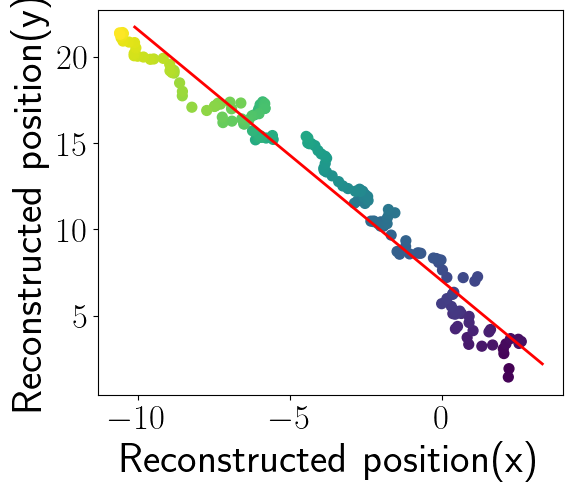

In [20]:
PC1_var, _ = analyze_linearity_with_pca(lifted_segment, plot_and_print=True)


In [21]:
# compute the linearity scoe of all segments

linearity_scores = []
for i in range(n_segments):
    segment_coords = tor_coord2[i*160:(i+1)*160]
    lifted_segment = toroidal_lifting_distance_upgrade(segment_coords)
    PC1_var, _ = analyze_linearity_with_pca(lifted_segment, plot_and_print=False)
    linearity_scores.append(PC1_var)

DISTANCE_THRESHOLD: 3.623891917901168
DISTANCE_THRESHOLD: 2.448868492013454
DISTANCE_THRESHOLD: 1.7625311838639135
DISTANCE_THRESHOLD: 0.9746002588108031
DISTANCE_THRESHOLD: 2.7352939905977314
DISTANCE_THRESHOLD: 1.269585106222272
DISTANCE_THRESHOLD: 3.3417523458735907
DISTANCE_THRESHOLD: 2.6588833953086883
DISTANCE_THRESHOLD: 3.770816417419648
DISTANCE_THRESHOLD: 0.30093023470937696
DISTANCE_THRESHOLD: 2.577399728748797
DISTANCE_THRESHOLD: 1.1919134872840447
DISTANCE_THRESHOLD: 0.45657974330813067
DISTANCE_THRESHOLD: 0.46336203093422057
DISTANCE_THRESHOLD: 3.2898362707797286
DISTANCE_THRESHOLD: 3.868861036262424
DISTANCE_THRESHOLD: 3.5410909205081653
DISTANCE_THRESHOLD: 3.2686719917281586
DISTANCE_THRESHOLD: 0.5135281946232757
DISTANCE_THRESHOLD: 0.506536317691296
DISTANCE_THRESHOLD: 1.1328677406418861
DISTANCE_THRESHOLD: 0.4325797309494619
DISTANCE_THRESHOLD: 0.25465998194699146
DISTANCE_THRESHOLD: 0.557221512271465
DISTANCE_THRESHOLD: 2.617089869152098
DISTANCE_THRESHOLD: 1.00148547

In [22]:
scores = np.array(list(linearity_scores))
print(f"Min linearity score: {scores.min():.4f}")
print(f"Mean linearity score: {scores.mean():.4f}")
print(f"Median linearity score: {np.median(scores):.4f}")

Min linearity score: 0.5945
Mean linearity score: 0.9661
Median linearity score: 0.9875


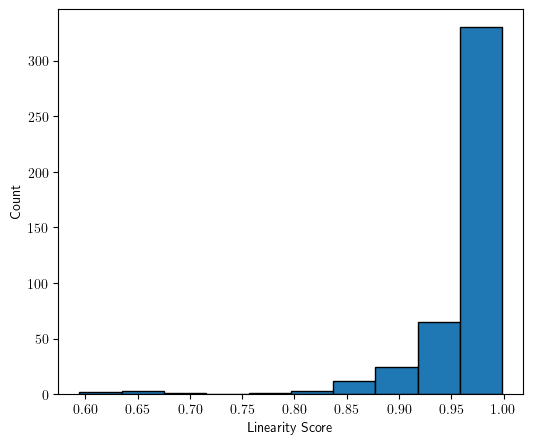

In [23]:
# plot histogram of linearity scores
plt.figure(figsize=(6,5))
plt.hist(scores, edgecolor='black')
plt.xlabel("Linearity Score")
plt.ylabel("Count")
plt.show()

## For comparison, let's compute the linearity scores of random 2D paths

In [27]:
import numpy as np
from constants import GRID_FIELDS_PATH

# load a simulated path from 0-hole world
data = np.load(os.path.join(GRID_FIELDS_PATH, "0_world_n2_results.npz"), allow_pickle=True)
processed_trace = data['processed_trace']        # (599999, 2)
print(f"Processed trace shape: {processed_trace.shape}")


Processed trace shape: (599999, 2)


In [28]:
seg_len = 10000
n_full = len(processed_trace) // seg_len
segments = [processed_trace[i*seg_len:(i+1)*seg_len] for i in range(n_full)]
if len(processed_trace) % seg_len != 0:
    segments.append(processed_trace[n_full*seg_len:])

In [29]:
random_segments_linearity_scores = []

for segment in segments:
    l_score, _ = analyze_linearity_with_pca(segment, plot_and_print=False)
    random_segments_linearity_scores.append(l_score)


print(f"Mean linearity score: {np.mean(random_segments_linearity_scores):.4f}")
print(f"Median linearity score: {np.median(random_segments_linearity_scores):.4f}")
print(f"Standard deviation of linearity scores: {np.std(random_segments_linearity_scores):.4f}")


Mean linearity score: 0.7821
Median linearity score: 0.7924
Standard deviation of linearity scores: 0.0984
